In [1]:
# Import visuals
import seaborn as sns
import matplotlib.pyplot as plt

# Import pandas
import pandas as pd

# Import numpy
import numpy as np

# Import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, r2_score

# Import scipy
from scipy.stats import boxcox
from scipy import stats

# Import Warnings
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for beautiful plots
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Load data (adjust path as needed)
df = pd.read_csv('contributions.csv')
df.head()

,ELECTION,OFFICECD,RECIPID,CANCLASS,RECIPNAME,COMMITTEE,FILING,SCHEDULE,PAGENO,SEQUENCENO,...,INTEMPSTNM,INTEMPCITY,INTEMPST,INTOCCUPA,PURPOSECD,EXEMPTCD,ADJTYPECD,RR_IND,SEG_IND,INT_C_CODE
0,2013,5,1751,P,"Brown, Ricardo A",H,9,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
1,2021,1,2563,P,"Tirschwell, Sara A",H,7,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
2,2021,11,1545,P,"Adams, Eric L",L,12,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
3,2017,5,530,NP,"Crowley, Elizabeth S",P,6,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN
4,2017,5,1990,P,"Brannan, Justin",H,7,ABC,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,NaN


## Data Preparation

Prepare donor-level features and aggregations for modeling.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

# Define settings
USE_EARLY_FEATURES_ONLY = False
USE_FULL_HISTORY_FEATURES = True
CUTOFF_DATE = "2019-12-31"

# Copy and clean
selected = df.copy()

# Parse date
selected['DATE_dt'] = pd.to_datetime(selected['DATE'], errors='coerce')

# Convert AMNT to numeric
selected['AMNT'] = pd.to_numeric(selected['AMNT'], errors='coerce')

# Filter positive amounts
selected = selected[selected['AMNT'] > 0].copy()

# Build donor_id (adjust as needed)
def build_donor_id(df):
    if 'NAME' in df.columns and 'ZIP' in df.columns:
        return (
            df['NAME'].astype(str).str.strip().str.lower() + '|' +
            df['ZIP'].astype(str).str.strip()
        )
    elif 'NAME' in df.columns:
        return df['NAME'].astype(str).str.strip().str.lower()
    else:
        return df.index.astype(str)

selected['donor_id'] = build_donor_id(selected)

# Aggregate donor totals
donor_total = selected.groupby('donor_id')['AMNT'].sum()

# Early vs full history split
if USE_EARLY_FEATURES_ONLY:
    cutoff_dt = pd.to_datetime(CUTOFF_DATE)
    early = selected[selected['DATE_dt'] <= cutoff_dt].copy()
    work = early
else:
    work = selected.copy()

# Build donor-level features
g = work.groupby('donor_id')
donor = pd.DataFrame({'donor_total': donor_total})

# Full-history behavioral features
if USE_FULL_HISTORY_FEATURES:
    donor['n_txn'] = g.size()
    donor['mean_amt'] = g['AMNT'].mean()
    donor['median_amt'] = g['AMNT'].median()
    donor['max_amt'] = g['AMNT'].max()

    span = g['DATE_dt'].max() - g['DATE_dt'].min()
    donor['span_days'] = span.dt.days.fillna(0).astype(float)

    donor['first_year'] = g['DATE_dt'].min().dt.year.fillna(0).astype(int)
    donor['last_year'] = g['DATE_dt'].max().dt.year.fillna(0).astype(int)

    if 'COMMITTEE' in work.columns:
        donor['n_committees'] = g['COMMITTEE'].nunique()
    if 'RECIPID' in work.columns:
        donor['n_recipients'] = g['RECIPID'].nunique()
    if 'PAY_METHOD' in work.columns:
        donor['n_pay_methods'] = g['PAY_METHOD'].nunique()

# Target
donor = donor.replace([np.inf, -np.inf], np.nan).dropna(subset=['donor_total'])
donor['y'] = np.log1p(donor['donor_total'])

# Sample if needed
MAX_DONORS = 150_000
if len(donor) > MAX_DONORS:
    donor = donor.sample(MAX_DONORS, random_state=42)

X = donor.drop(columns=['donor_total','y'])
y = donor['y']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

try:
    ohe = OneHotEncoder(handle_unknown='ignore', min_frequency=50)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore')

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=False), num_cols),
        ('cat', ohe, cat_cols),
    ],
    remainder='drop'
)

model = Pipeline(steps=[
    ('prep', preprocess),
    ('reg', Ridge(alpha=1.0, random_state=42))
])

model.fit(X_train, y_train)

# Evaluate
pred = model.predict(X_test)
r2 = r2_score(y_test, pred)
mae_log = mean_absolute_error(y_test, pred)

print(f"R² (log scale): {r2:.3f}")
print(f"MAE (log scale): {mae_log:.3f}")

mae_dollars_proxy = np.median(np.abs(np.expm1(y_test) - np.expm1(pred)))
print(f"Median absolute error (≈ dollars): {mae_dollars_proxy:,.0f}")

# Permutation importance
PERM_SAMPLE = 20_000
if len(X_test) > PERM_SAMPLE:
    X_pi = X_test.sample(PERM_SAMPLE, random_state=42)
    y_pi = y_test.loc[X_pi.index]
else:
    X_pi, y_pi = X_test, y_test

perm = permutation_importance(
    model, X_pi, y_pi,
    n_repeats=3,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
display(imp.head(25))

R² (log scale): -2.419
MAE (log scale): 1.120
Median absolute error (≈ dollars): 61


mean_amt         35.497218
max_amt          21.694406
first_year        0.131959
last_year         0.108385
span_days         0.028062
n_committees      0.017036
n_recipients      0.010193
n_pay_methods    -0.001189
n_txn            -0.004430
median_amt       -1.157347
dtype: float64

## Seaborn Visualizations


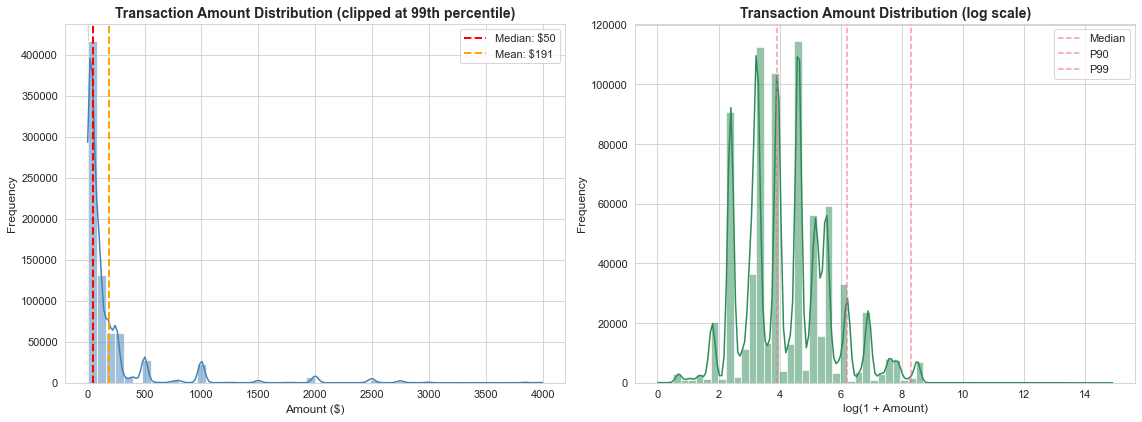

In [4]:
# 1) Distribution of Transaction Amounts with KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original scale (with outliers clipped for visibility)
amt_data = selected['AMNT'][selected['AMNT'] <= selected['AMNT'].quantile(0.99)]
sns.histplot(amt_data, bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (clipped at 99th percentile)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(amt_data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${amt_data.median():.0f}')
axes[0].axvline(amt_data.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: ${amt_data.mean():.0f}')
axes[0].legend()

# Log scale
sns.histplot(np.log1p(selected['AMNT']), bins=60, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title('Transaction Amount Distribution (log scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Add quantile lines
for q, label in [(0.5, 'Median'), (0.9, 'P90'), (0.99, 'P99')]:
    val = np.log1p(selected['AMNT'].quantile(q))
    axes[1].axvline(val, linestyle='--', linewidth=1.5, alpha=0.7, label=f'{label}')
axes[1].legend()

plt.tight_layout()
plt.show()

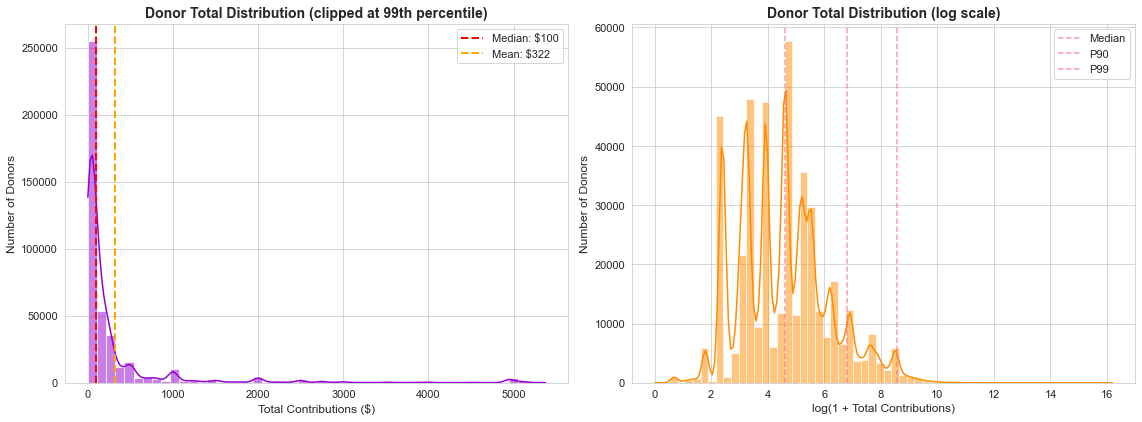

In [5]:
# 2) Donor Total Distribution with KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original scale (clipped)
donor_total_clipped = donor_total[donor_total <= donor_total.quantile(0.99)]
sns.histplot(donor_total_clipped, bins=50, kde=True, color='darkviolet', ax=axes[0])
axes[0].set_title('Donor Total Distribution (clipped at 99th percentile)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Contributions ($)', fontsize=12)
axes[0].set_ylabel('Number of Donors', fontsize=12)
axes[0].axvline(donor_total_clipped.median(), color='red', linestyle='--', linewidth=2, 
                label=f'Median: ${donor_total_clipped.median():.0f}')
axes[0].axvline(donor_total_clipped.mean(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mean: ${donor_total_clipped.mean():.0f}')
axes[0].legend()

# Log scale
sns.histplot(np.log1p(donor_total), bins=60, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Donor Total Distribution (log scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + Total Contributions)', fontsize=12)
axes[1].set_ylabel('Number of Donors', fontsize=12)

for q, label in [(0.5, 'Median'), (0.9, 'P90'), (0.99, 'P99')]:
    val = np.log1p(donor_total.quantile(q))
    axes[1].axvline(val, linestyle='--', linewidth=1.5, alpha=0.7, label=f'{label}')
axes[1].legend()

plt.tight_layout()
plt.show()

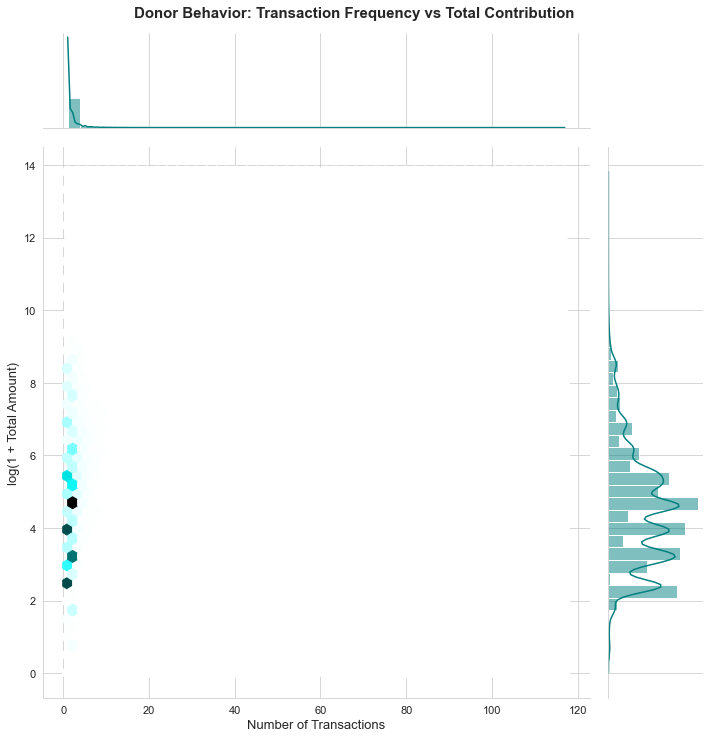

In [6]:
# 3) Donor Behavior: Number of Transactions vs Total Amount
n_txn = selected.groupby('donor_id')['AMNT'].size()
behavior_df = pd.DataFrame({
    'n_transactions': n_txn,
    'total_amount': donor_total,
    'log_total': np.log1p(donor_total)
}).dropna()

# Sample for visualization if too large
if len(behavior_df) > 50000:
    behavior_sample = behavior_df.sample(50000, random_state=42)
else:
    behavior_sample = behavior_df

# Joint plot showing relationship and distributions
g = sns.jointplot(data=behavior_sample, x='n_transactions', y='log_total', 
                  kind='hex', height=10, color='teal',
                  marginal_kws=dict(bins=40, kde=True))
g.set_axis_labels('Number of Transactions', 'log(1 + Total Amount)', fontsize=13)
g.fig.suptitle('Donor Behavior: Transaction Frequency vs Total Contribution', 
               fontsize=15, fontweight='bold', y=1.02)
plt.show()

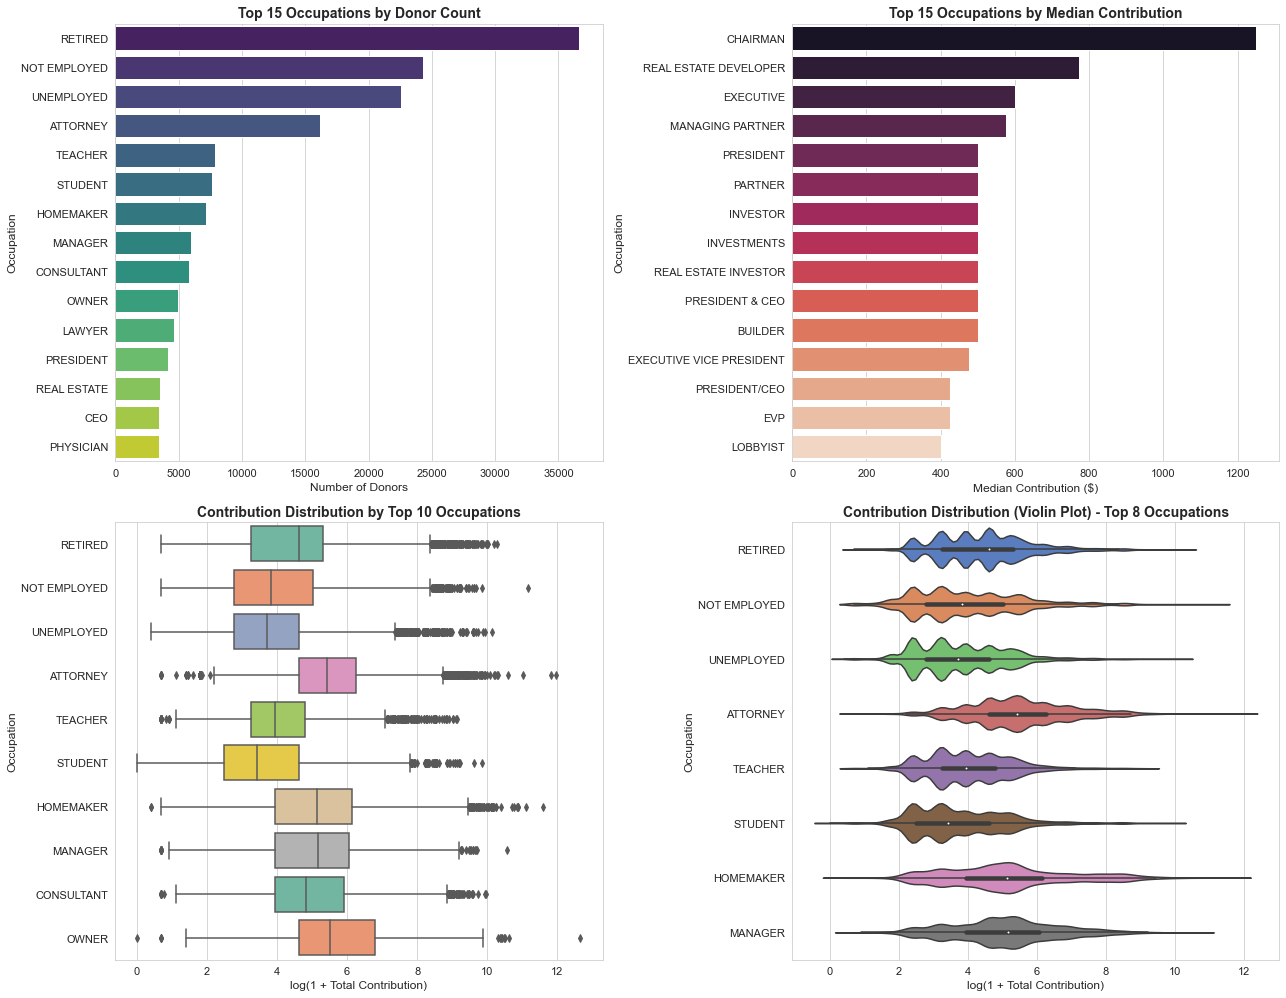


Top 15 Occupations Summary:
              count  median         mean  total_raised
job                                                   
RETIRED       36644   100.0   272.816154    9997075.15
NOT EMPLOYED  24322    45.0   244.453602    5945600.52
UNEMPLOYED    22561    40.0   152.146490    3432576.96
ATTORNEY      16174   225.0   738.214668   11939884.04
TEACHER        7873    50.0   146.384863    1152488.03
STUDENT        7652    30.0   168.536351    1289640.16
HOMEMAKER      7182   170.0   951.828205    6836030.17
MANAGER        5987   175.0   523.700648    3135395.78
CONSULTANT     5789   125.0   533.911501    3090813.68
OWNER          4976   250.0   969.768798    4825569.54
LAWYER         4632   200.0   744.320918    3447694.49
PRESIDENT      4146   500.0  1423.341840    5901175.27
REAL ESTATE    3553   350.0  4375.681039   15546794.73
CEO            3439   375.0  4505.855121   15495635.76
PHYSICIAN      3432   200.0   528.990219    1815494.43


In [7]:
# 4) Top Occupations Analysis
# Find occupation column
job_col = None
for col in ['OCCUPATION', 'OCCUP', 'JOB', 'Jobs']:
    if col in selected.columns:
        job_col = col
        break

if job_col is not None:
    # Get first job per donor
    work_sorted = selected.sort_values(['donor_id', 'DATE_dt'])
    donor_job = work_sorted.groupby('donor_id')[job_col].first()
    
    job_analysis = pd.DataFrame({
        'job': donor_job,
        'total': donor_total
    }).dropna()
    
    job_analysis['job'] = job_analysis['job'].astype(str).str.strip().str.upper()
    
    # Get top jobs by count (minimum 100 donors for stable stats)
    job_stats = job_analysis.groupby('job').agg(
        count=('total', 'count'),
        median=('total', 'median'),
        mean=('total', 'mean'),
        total_raised=('total', 'sum')
    ).sort_values('count', ascending=False)
    
    top_jobs = job_stats[job_stats['count'] >= 100].head(15)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # A) Top jobs by donor count
    sns.barplot(data=top_jobs.reset_index(), y='job', x='count', 
                palette='viridis', ax=axes[0, 0])
    axes[0, 0].set_title('Top 15 Occupations by Donor Count', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Number of Donors', fontsize=12)
    axes[0, 0].set_ylabel('Occupation', fontsize=12)
    
    # B) Top jobs by median contribution
    top_by_median = job_stats[job_stats['count'] >= 100].nlargest(15, 'median')
    sns.barplot(data=top_by_median.reset_index(), y='job', x='median', 
                palette='rocket', ax=axes[0, 1])
    axes[0, 1].set_title('Top 15 Occupations by Median Contribution', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Median Contribution ($)', fontsize=12)
    axes[0, 1].set_ylabel('Occupation', fontsize=12)
    
    # C) Boxplot of top occupations
    top_job_names = top_jobs.head(10).index.tolist()
    plot_data = job_analysis[job_analysis['job'].isin(top_job_names)].copy()
    plot_data['log_total'] = np.log1p(plot_data['total'])
    
    sns.boxplot(data=plot_data, y='job', x='log_total', 
                order=top_job_names, palette='Set2', ax=axes[1, 0])
    axes[1, 0].set_title('Contribution Distribution by Top 10 Occupations', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('log(1 + Total Contribution)', fontsize=12)
    axes[1, 0].set_ylabel('Occupation', fontsize=12)
    
    # D) Violin plot for detailed distribution
    sns.violinplot(data=plot_data, y='job', x='log_total', 
                   order=top_job_names[:8], palette='muted', ax=axes[1, 1])
    axes[1, 1].set_title('Contribution Distribution (Violin Plot) - Top 8 Occupations', 
                         fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('log(1 + Total Contribution)', fontsize=12)
    axes[1, 1].set_ylabel('Occupation', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 15 Occupations Summary:")
    print(top_jobs[['count', 'median', 'mean', 'total_raised']].to_string())
else:
    print("No occupation column found in the dataset.")

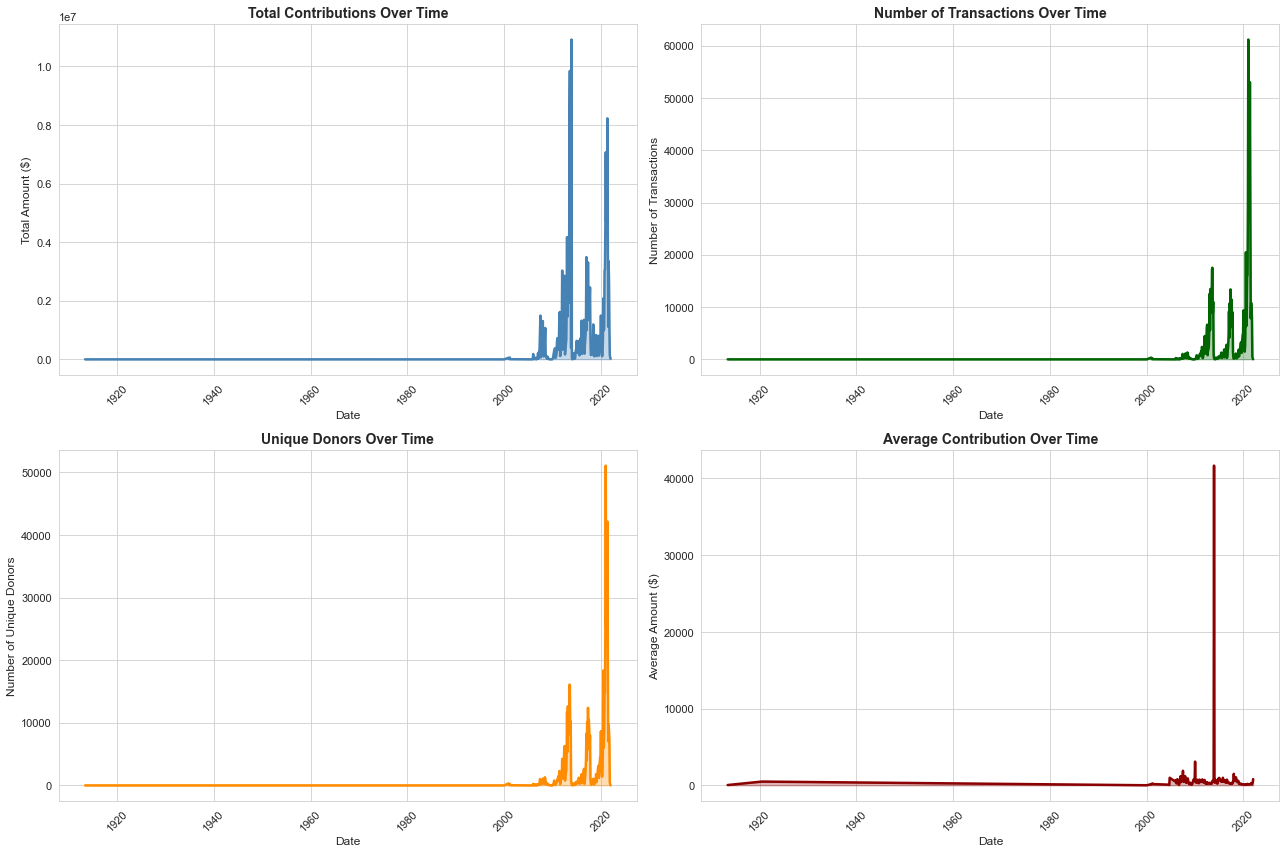

In [8]:
# 5) Time Series Analysis (if date available)
if 'DATE_dt' in selected.columns:
    # Aggregate by month
    selected['year_month'] = selected['DATE_dt'].dt.to_period('M')
    monthly_stats = selected.groupby('year_month').agg(
        total_amount=('AMNT', 'sum'),
        num_transactions=('AMNT', 'count'),
        num_donors=('donor_id', 'nunique'),
        avg_amount=('AMNT', 'mean')
    ).reset_index()
    monthly_stats['year_month'] = monthly_stats['year_month'].dt.to_timestamp()
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Total amount over time
    sns.lineplot(data=monthly_stats, x='year_month', y='total_amount', 
                 color='steelblue', linewidth=2.5, ax=axes[0, 0])
    axes[0, 0].fill_between(monthly_stats['year_month'], monthly_stats['total_amount'], 
                            alpha=0.3, color='steelblue')
    axes[0, 0].set_title('Total Contributions Over Time', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Date', fontsize=12)
    axes[0, 0].set_ylabel('Total Amount ($)', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Number of transactions over time
    sns.lineplot(data=monthly_stats, x='year_month', y='num_transactions', 
                 color='darkgreen', linewidth=2.5, ax=axes[0, 1])
    axes[0, 1].fill_between(monthly_stats['year_month'], monthly_stats['num_transactions'], 
                            alpha=0.3, color='darkgreen')
    axes[0, 1].set_title('Number of Transactions Over Time', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Date', fontsize=12)
    axes[0, 1].set_ylabel('Number of Transactions', fontsize=12)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Unique donors over time
    sns.lineplot(data=monthly_stats, x='year_month', y='num_donors', 
                 color='darkorange', linewidth=2.5, ax=axes[1, 0])
    axes[1, 0].fill_between(monthly_stats['year_month'], monthly_stats['num_donors'], 
                            alpha=0.3, color='darkorange')
    axes[1, 0].set_title('Unique Donors Over Time', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Date', fontsize=12)
    axes[1, 0].set_ylabel('Number of Unique Donors', fontsize=12)
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Average contribution over time
    sns.lineplot(data=monthly_stats, x='year_month', y='avg_amount', 
                 color='darkred', linewidth=2.5, ax=axes[1, 1])
    axes[1, 1].fill_between(monthly_stats['year_month'], monthly_stats['avg_amount'], 
                            alpha=0.3, color='darkred')
    axes[1, 1].set_title('Average Contribution Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Date', fontsize=12)
    axes[1, 1].set_ylabel('Average Amount ($)', fontsize=12)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

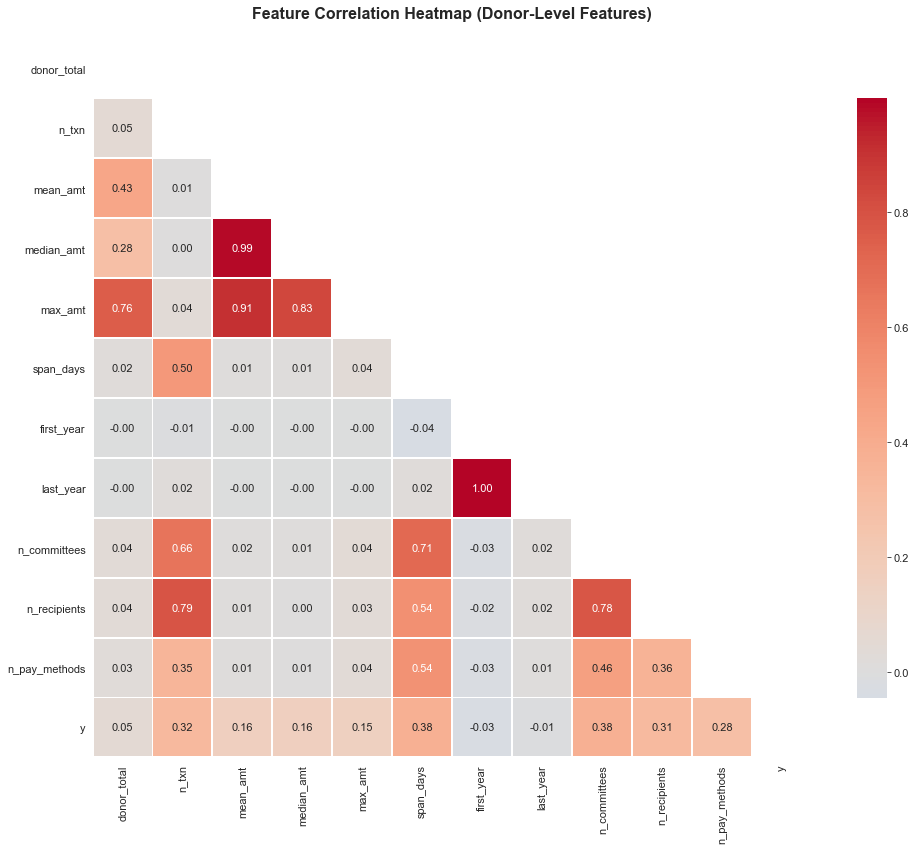

In [9]:
# 6) Feature Correlation Heatmap
if 'donor' in locals() and len(donor.select_dtypes(include=[np.number]).columns) > 1:
    numeric_features = donor.select_dtypes(include=[np.number])
    
    # Calculate correlation
    corr_matrix = numeric_features.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Plot
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, linewidths=1,
                cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap (Donor-Level Features)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

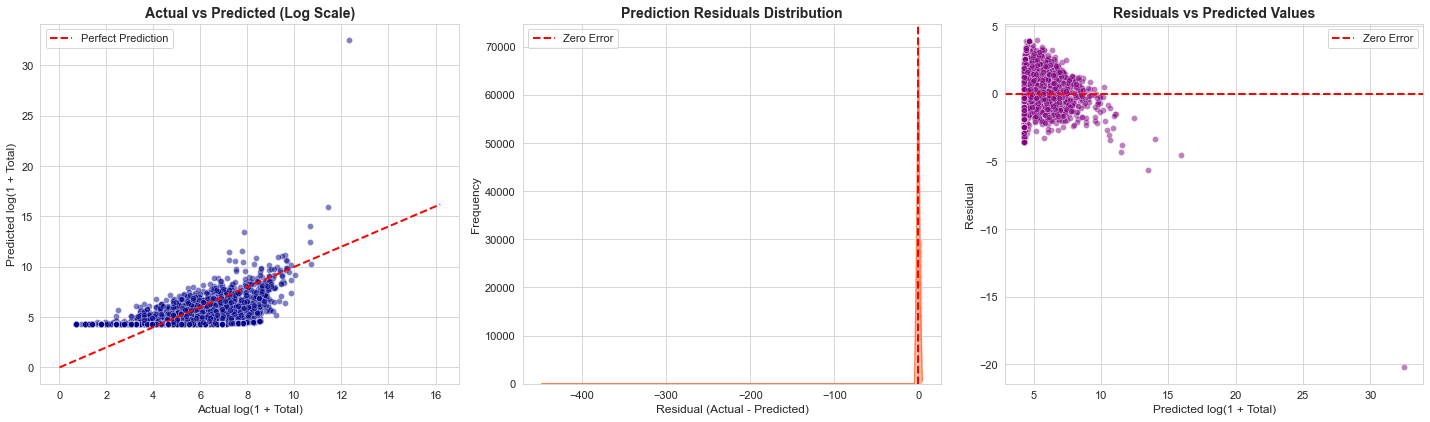


Model Performance Metrics:
R² Score: -2.4189
MAE (log scale): 1.1204
RMSE (log scale): 2.9264
Median Absolute Error ($): $61


In [10]:
# 7) Model Performance Visualization
if 'pred' in locals() and 'y_test' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # A) Actual vs Predicted (log scale)
    sample_size = min(10000, len(y_test))
    sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
    
    sns.scatterplot(x=y_test.iloc[sample_idx], y=pred[sample_idx], 
                    alpha=0.5, color='darkblue', ax=axes[0])
    # Add perfect prediction line
    min_val, max_val = y_test.min(), y_test.max()
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_title('Actual vs Predicted (Log Scale)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Actual log(1 + Total)', fontsize=12)
    axes[0].set_ylabel('Predicted log(1 + Total)', fontsize=12)
    axes[0].legend()
    
    # B) Residuals
    residuals = y_test - pred
    sns.histplot(residuals, bins=50, kde=True, color='coral', ax=axes[1])
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[1].set_title('Prediction Residuals Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].legend()
    
    # C) Residuals vs Predicted
    sns.scatterplot(x=pred[sample_idx], y=residuals.iloc[sample_idx], 
                    alpha=0.5, color='purple', ax=axes[2])
    axes[2].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[2].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Predicted log(1 + Total)', fontsize=12)
    axes[2].set_ylabel('Residual', fontsize=12)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print performance metrics
    print(f"\nModel Performance Metrics:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE (log scale): {mae_log:.4f}")
    print(f"RMSE (log scale): {np.sqrt(np.mean(residuals**2)):.4f}")
    print(f"Median Absolute Error ($): ${mae_dollars_proxy:,.0f}")

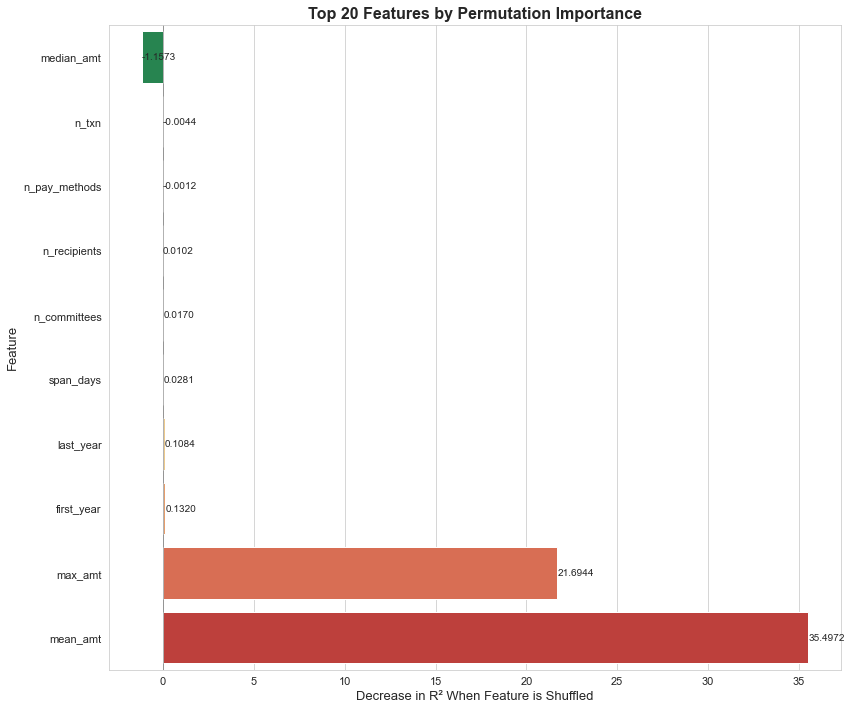

In [11]:
# 8) Feature Importance Visualization (Enhanced)
if 'imp' in locals():
    top_features = imp.head(20).sort_values()
    
    plt.figure(figsize=(12, 10))
    colors = sns.color_palette('RdYlGn_r', len(top_features))
    sns.barplot(x=top_features.values, y=top_features.index, palette=colors)
    plt.title('Top 20 Features by Permutation Importance', fontsize=16, fontweight='bold')
    plt.xlabel('Decrease in R² When Feature is Shuffled', fontsize=13)
    plt.ylabel('Feature', fontsize=13)
    plt.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(top_features.values):
        plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

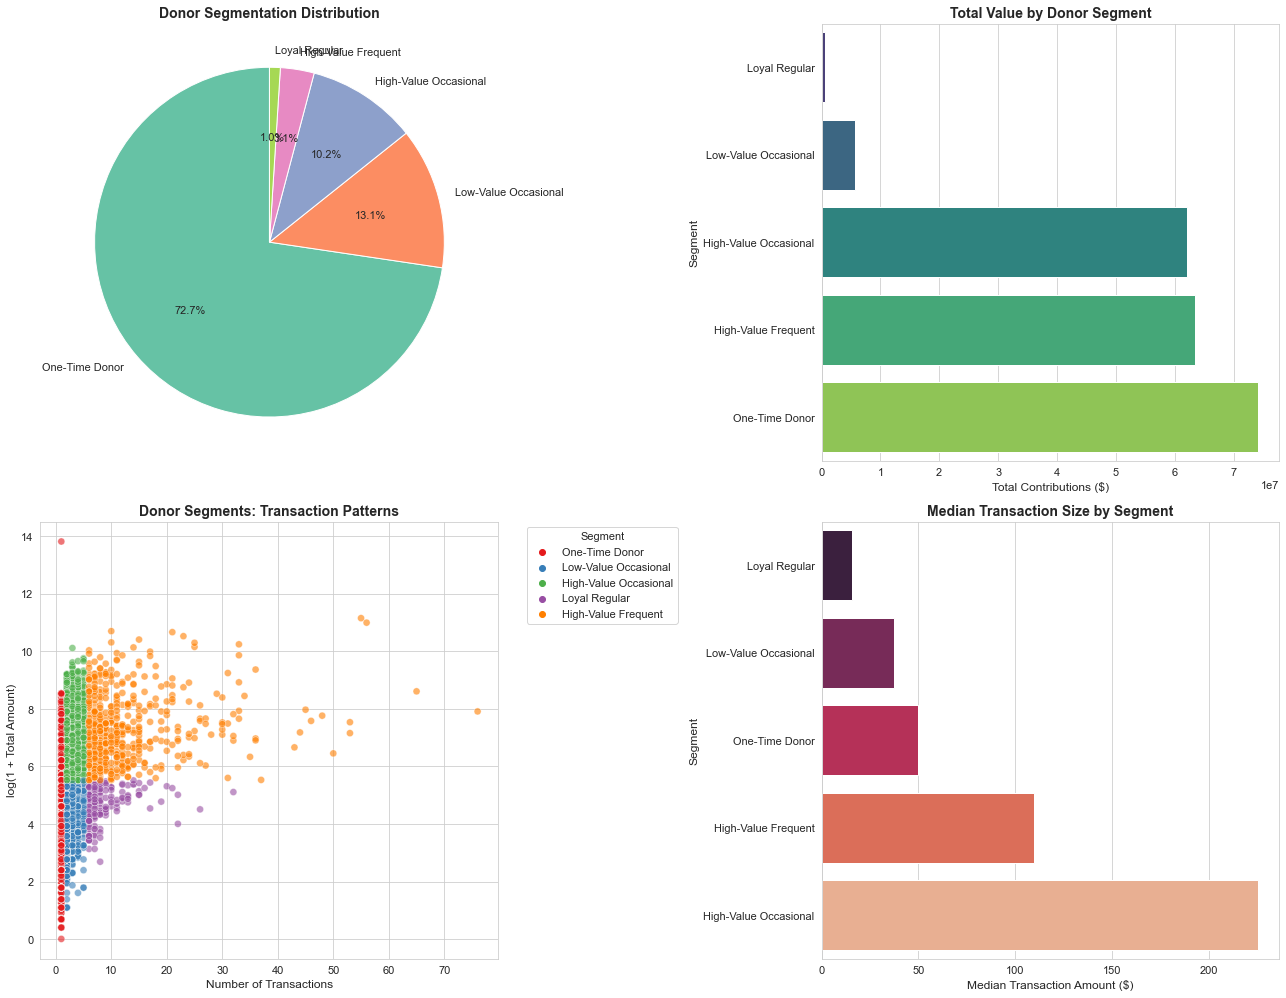


Donor Segment Statistics:
                      n_transactions        total_amount                   \
                               count   mean          sum     mean  median   
segment                                                                     
High-Value Frequent            13285  11.57  63429098.09  4774.49  1050.0   
High-Value Occasional          43293   2.86  62097871.46  1434.36   600.0   
Low-Value Occasional           55581   2.49   5674276.16   102.09    95.0   
Loyal Regular                   4243   8.45    558211.81   131.56   133.1   
One-Time Donor                309248   1.00  74091071.40   239.58    50.0   

                      avg_per_txn  
                           median  
segment                            
High-Value Frequent        109.38  
High-Value Occasional      225.00  
Low-Value Occasional        37.50  
Loyal Regular               15.55  
One-Time Donor              50.00  


In [12]:
# 9) Donor Segmentation: Contribution Patterns
if 'behavior_df' in locals():
    # Create donor segments based on behavior
    behavior_df['avg_per_txn'] = behavior_df['total_amount'] / behavior_df['n_transactions']
    
    # Define segments
    def segment_donor(row):
        if row['n_transactions'] == 1:
            return 'One-Time Donor'
        elif row['n_transactions'] <= 5:
            if row['total_amount'] >= behavior_df['total_amount'].quantile(0.75):
                return 'High-Value Occasional'
            else:
                return 'Low-Value Occasional'
        else:
            if row['total_amount'] >= behavior_df['total_amount'].quantile(0.75):
                return 'High-Value Frequent'
            else:
                return 'Loyal Regular'
    
    behavior_df['segment'] = behavior_df.apply(segment_donor, axis=1)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # A) Segment distribution
    segment_counts = behavior_df['segment'].value_counts()
    colors_pie = sns.color_palette('Set2', len(segment_counts))
    axes[0, 0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
                   colors=colors_pie, startangle=90)
    axes[0, 0].set_title('Donor Segmentation Distribution', fontsize=14, fontweight='bold')
    
    # B) Segment value contribution
    segment_value = behavior_df.groupby('segment')['total_amount'].sum().sort_values()
    sns.barplot(x=segment_value.values, y=segment_value.index, palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title('Total Value by Donor Segment', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Total Contributions ($)', fontsize=12)
    axes[0, 1].set_ylabel('Segment', fontsize=12)
    
    # C) Segment behavior patterns (log scale)
    plot_sample = behavior_df.sample(min(20000, len(behavior_df)), random_state=42)
    sns.scatterplot(data=plot_sample, x='n_transactions', y='log_total', 
                    hue='segment', palette='Set1', alpha=0.6, s=50, ax=axes[1, 0])
    axes[1, 0].set_title('Donor Segments: Transaction Patterns', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Transactions', fontsize=12)
    axes[1, 0].set_ylabel('log(1 + Total Amount)', fontsize=12)
    axes[1, 0].legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # D) Average transaction size by segment
    avg_txn_by_segment = behavior_df.groupby('segment')['avg_per_txn'].median().sort_values()
    sns.barplot(x=avg_txn_by_segment.values, y=avg_txn_by_segment.index, 
                palette='rocket', ax=axes[1, 1])
    axes[1, 1].set_title('Median Transaction Size by Segment', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Median Transaction Amount ($)', fontsize=12)
    axes[1, 1].set_ylabel('Segment', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print segment statistics
    print("\nDonor Segment Statistics:")
    segment_stats = behavior_df.groupby('segment').agg({
        'n_transactions': ['count', 'mean'],
        'total_amount': ['sum', 'mean', 'median'],
        'avg_per_txn': 'median'
    }).round(2)
    print(segment_stats)

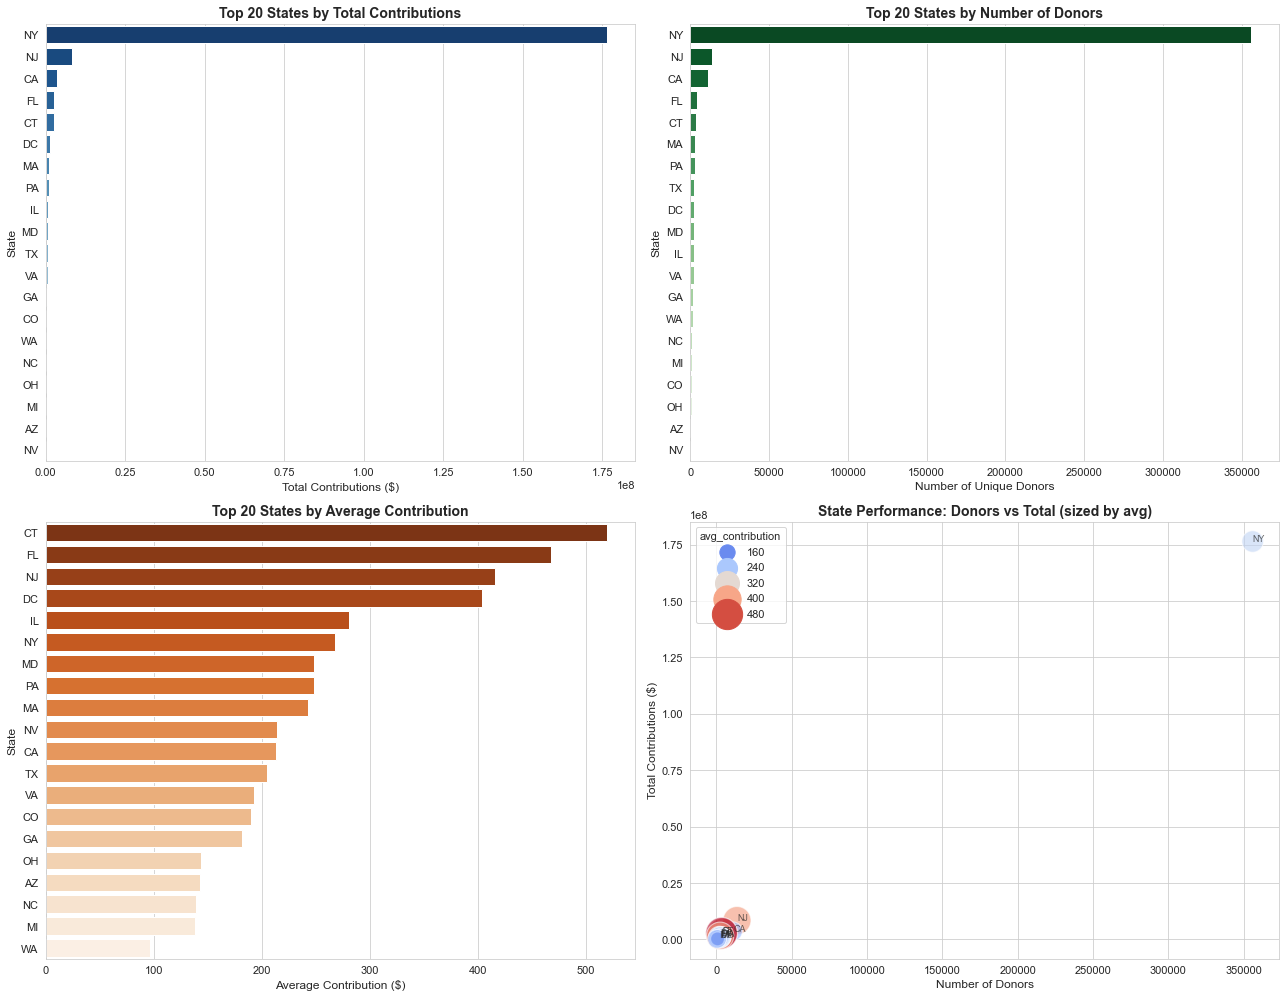

In [13]:
# 10) Geographic Analysis (if state/zip data available)
state_col = None
for col in ['STATE', 'ST', 'State']:
    if col in selected.columns:
        state_col = col
        break

if state_col is not None:
    state_analysis = selected.groupby(state_col).agg(
        total_amount=('AMNT', 'sum'),
        num_donors=('donor_id', 'nunique'),
        num_transactions=('AMNT', 'count'),
        avg_contribution=('AMNT', 'mean')
    ).sort_values('total_amount', ascending=False).head(20)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # A) Top states by total contributions
    sns.barplot(data=state_analysis.reset_index(), y=state_col, x='total_amount', 
                palette='Blues_r', ax=axes[0, 0])
    axes[0, 0].set_title('Top 20 States by Total Contributions', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Total Contributions ($)', fontsize=12)
    axes[0, 0].set_ylabel('State', fontsize=12)
    
    # B) Top states by number of donors
    top_by_donors = state_analysis.sort_values('num_donors', ascending=False).head(20)
    sns.barplot(data=top_by_donors.reset_index(), y=state_col, x='num_donors', 
                palette='Greens_r', ax=axes[0, 1])
    axes[0, 1].set_title('Top 20 States by Number of Donors', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Unique Donors', fontsize=12)
    axes[0, 1].set_ylabel('State', fontsize=12)
    
    # C) Average contribution by state
    top_by_avg = state_analysis.sort_values('avg_contribution', ascending=False).head(20)
    sns.barplot(data=top_by_avg.reset_index(), y=state_col, x='avg_contribution', 
                palette='Oranges_r', ax=axes[1, 0])
    axes[1, 0].set_title('Top 20 States by Average Contribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Average Contribution ($)', fontsize=12)
    axes[1, 0].set_ylabel('State', fontsize=12)
    
    # D) Scatter: total vs donors
    sns.scatterplot(data=state_analysis.reset_index(), x='num_donors', y='total_amount',
                    size='avg_contribution', sizes=(100, 1000), alpha=0.6,
                    hue='avg_contribution', palette='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('State Performance: Donors vs Total (sized by avg)', 
                         fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Donors', fontsize=12)
    axes[1, 1].set_ylabel('Total Contributions ($)', fontsize=12)
    
    # Add state labels for top performers
    for idx, row in state_analysis.head(10).iterrows():
        axes[1, 1].annotate(idx, 
                           (row['num_donors'], row['total_amount']),
                           fontsize=9, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print("No state column found for geographic analysis.")

## Summary of Visualizations

1. **Distribution Analysis**: Transaction and donor total distributions with KDE overlays
2. **Behavioral Insights**: Joint plots showing transaction frequency vs contribution amounts
3. **Occupation Analysis**: Multi-panel analysis of top occupations with boxplots and violin plots
4. **Time Series**: Monthly trends in contributions, transactions, and donor activity
5. **Correlation Heatmaps**: Feature relationships for model inputs
6. **Model Performance**: Actual vs predicted plots with residual analysis
7. **Feature Importance**: Enhanced bar charts with color gradients
8. **Donor Segmentation**: Pie charts and scatter plots showing donor behavior patterns
9. **Geographic Analysis**: State-level contribution patterns and performance metrics
